#Student Performance Analysis & Prediction

## Task1-Data Exploration with Pandas

In [18]:
import pandas as pd

In [ ]:
#loading dataset
df = pd.read_csv("students.csv")
#preview first few rows
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [10]:
print("First 5 rows of dataset:")
df.head()

First 5 rows of dataset:


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [11]:
print("Shape of dataset (rows, columns):")
df.shape

Shape of dataset (rows, columns):


(15, 9)

In [12]:
print("Data types of each column:")
df.dtypes

Data types of each column:


name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

In [13]:
print("Summary statistics:")
df.describe()

Summary statistics:


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [14]:
print("Pass / Fail count:")
df['passed'].value_counts()

Pass / Fail count:


passed
1    9
0    6
Name: count, dtype: int64

## Average Scores Analysis

Now compare subject-wise averages between:
-Students who passed
-Students who failed

In [ ]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

#average for passed students
passed_avg = df[df['passed'] == 1][subject_cols].mean()

print("Average subject scores (Passed students):")
passed_avg

Average subject scores (Passed students):


math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

In [ ]:
#average for failed students
failed_avg = df[df['passed'] == 0][subject_cols].mean()

print("Average subject scores (Failed students):")
failed_avg

Average subject scores (Failed students):


math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

## Top Performing Student

calculate overall average across all subjects to find the top performer.

In [ ]:
#create new column for average marks
df['avg_score'] = df[subject_cols].mean(axis=1)

#find student with highest average
top_student = df.loc[df['avg_score'].idxmax()]

print("Top performing student:")
print(top_student['name'], "with avg score =", round(top_student['avg_score'], 2))

Top performing student:
Diana with avg score = 94.0


## Task2-Data Visualization with Matplotlib

create different plots to analyze student performance visually.

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [ ]:
df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']

#adding avg score column
df['avg_score'] = df[subject_cols].mean(axis=1)

df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed,avg_score
0,Alice,88,92,76,80,95,92,4.5,1,86.2
1,Bob,42,55,48,50,60,65,1.2,0,51.0
2,Charlie,75,70,80,68,88,85,3.0,1,76.2
3,Diana,95,98,91,89,97,98,6.0,1,94.0
4,Eve,38,42,50,45,55,58,0.8,0,46.0


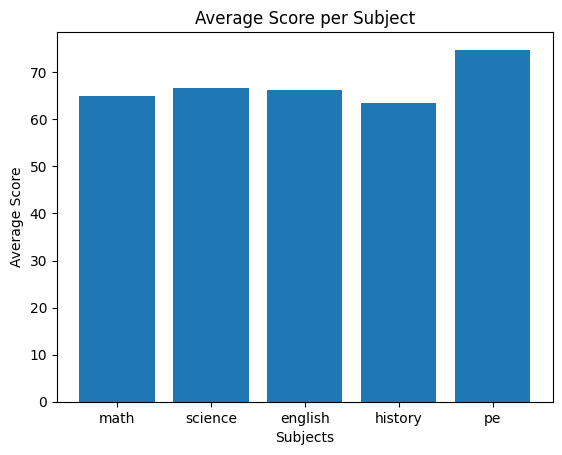

In [ ]:
#calculate average per subject
avg_scores = df[subject_cols].mean()

#Bar Chart
plt.figure()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

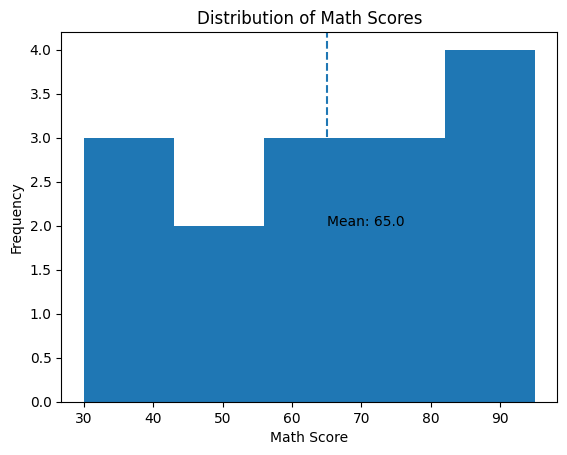

In [23]:
math_scores = df['math']
mean_math = math_scores.mean()

#Histogram
plt.figure()
plt.hist(math_scores, bins=5)

#mean line
plt.axvline(mean_math, linestyle='--')
plt.text(mean_math, 2, f"Mean: {round(mean_math,2)}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.savefig("plot2_histogram.png")
plt.show()

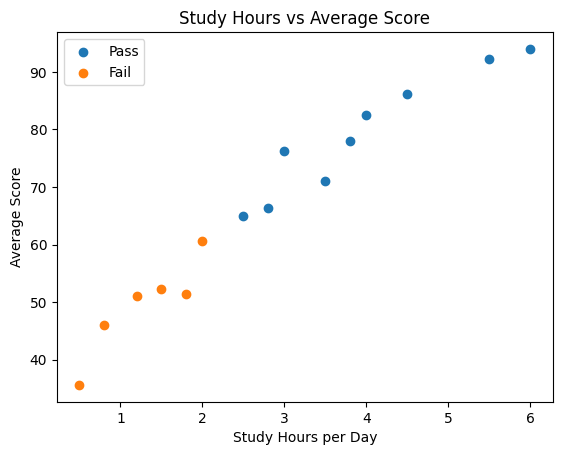

In [24]:
#separate pass and fail
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

#Scatter Plot
plt.figure()

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

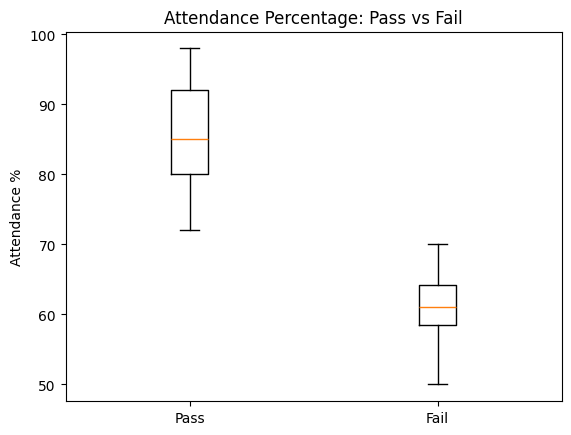

In [28]:
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

#Box Plot
plt.figure()

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title("Attendance Percentage: Pass vs Fail")
plt.ylabel("Attendance %")

plt.savefig("plot4_boxplot.png")
plt.show()

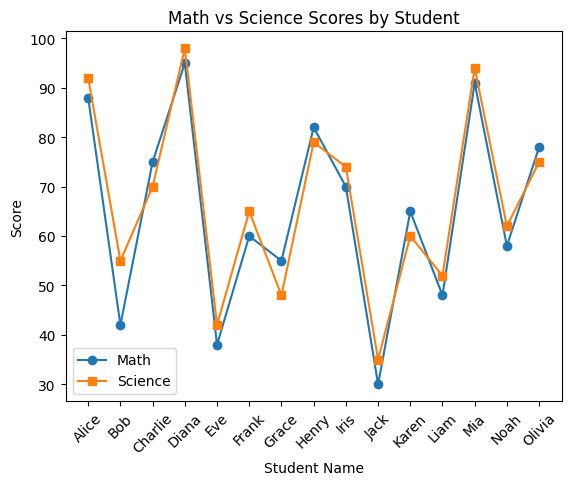

In [ ]:
names = df['name']

#Line Plot

plt.figure()

plt.plot(names, df['math'], marker='o', label='Math')
plt.plot(names, df['science'], marker='s', label='Science')

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show() 

## Task 3-Data Visualization with Seaborn

using Seaborn to create more advanced and visually appealing plots.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed,avg_score
0,Alice,88,92,76,80,95,92,4.5,1,86.2
1,Bob,42,55,48,50,60,65,1.2,0,51.0
2,Charlie,75,70,80,68,88,85,3.0,1,76.2
3,Diana,95,98,91,89,97,98,6.0,1,94.0
4,Eve,38,42,50,45,55,58,0.8,0,46.0


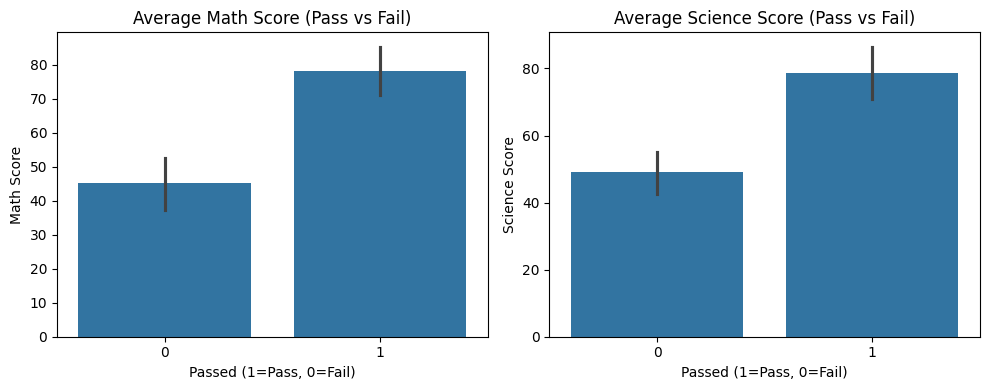

In [ ]:
#Seaborn bar plot
plt.figure(figsize=(10, 4))

#subplot 1-math
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Math Score")

#subplot 2-science
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

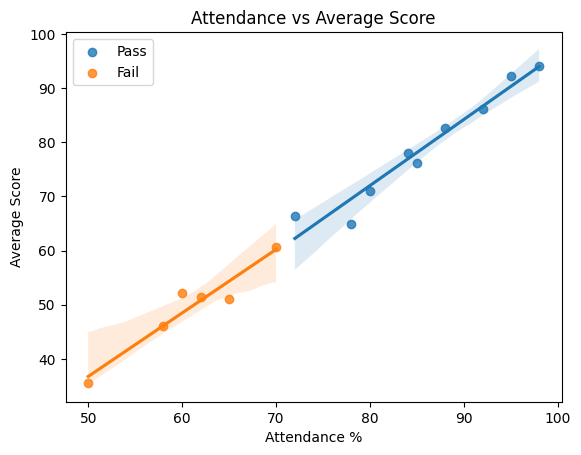

In [ ]:
#Seaborn scatter plot
plt.figure()

#regression for Pass students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)

#regression for Fail students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [ ]:
#Seaborn was easier to use for plots like barplot and regression plots,
#because it automatically calculates averages and fits trend lines.
#Compared to Matplotlib, Seaborn required less manual work and produced better-looking plots by default.
#However, Matplotlib gives more control when customizing plots in detail.

## Task 4-Machine Learning with scikit-learn

In this task, we build a model to predict whether a student will pass or fail.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [37]:
df = pd.read_csv("students.csv")

df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


Step1-Prepare Data

In [ ]:
#selecting features (excluding name)
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

In [ ]:
#split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 12
Test size: 3


In [ ]:
scaler = StandardScaler()

#fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

#transform test data
X_test_scaled = scaler.transform(X_test)

Step2-Train Model

In [ ]:
model = LogisticRegression()

#train model
model.fit(X_train_scaled, y_train)

#training accuracy
train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", round(train_acc, 2))

Training Accuracy: 1.0


Step3-Evaluate Model

In [ ]:
#predict on test data
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(test_acc, 2))

Test Accuracy: 1.0


In [43]:
print("\nTest Predictions:\n")

for i in range(len(X_test)):
    idx = X_test.index[i]
    
    name = df.loc[idx, 'name']
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    
    result = "✅ Correct" if actual == predicted else "❌ Wrong"
    
    print(f"{name} → Actual: {actual}, Predicted: {predicted} → {result}")


Test Predictions:

Jack → Actual: 0, Predicted: 0 → ✅ Correct
Liam → Actual: 0, Predicted: 0 → ✅ Correct
Alice → Actual: 1, Predicted: 1 → ✅ Correct


Step4-Feature Importance

In [ ]:
#get coefficients
coeffs = model.coef_[0]

#pair with feature names
feature_importance = list(zip(feature_cols, coeffs))

#sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("Feature Importance (sorted):\n")

for feature, coef in feature_importance:
    print(f"{feature}: {round(coef, 3)}")

Feature Importance (sorted):

english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


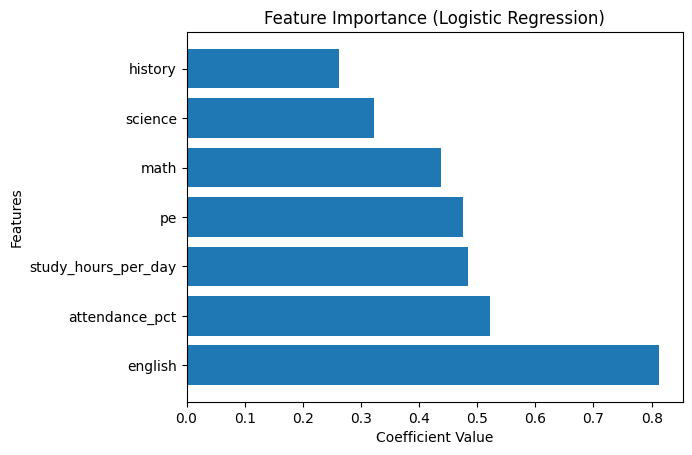

In [ ]:
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

#color based on sign
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()

plt.barh(features, values)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.savefig("plot8_feature_importance.png")
plt.show()

Step5- Predict New Student

In [ ]:
#new student data
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=feature_cols
)

#scale
new_student_scaled = scaler.transform(new_student)

#prediction
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("Prediction for new student:", result)
print("Probability [Fail, Pass]:", probability)

Prediction for new student: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]
